# WGC Engine-Start Feature Engineering

**Project:** Multi-Sensor Analysis of Mid-Flight Engine Starts in Motorized Sailplanes

## Project Objective

Notebook 4 identified preliminary engine-start candidates from the sponsor-provided IGC flight logs. The purpose of this notebook is to prepare those candidates for later classification by creating consistent event-level features.

The features developed here describe:

1. The motor-related evidence recorded during each candidate.
2. The aircraft's behavior before and after the candidate.
3. The amount and quality of evidence available for each event.
4. The altitude and location information needed for later AGL and compliance analysis.

This notebook does not assign final labels such as successful, failed, false positive, or indeterminate. Those outcomes will be assigned after the feature dataset is reviewed, sponsor-confirmed examples are connected, and the team’s decision-tree criteria are finalized.

## 1. Imports and File Paths

This section loads the required Python packages and defines the locations of the candidate-event data, flight inventory, processed outputs, and saved figures.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROCESSED_DATA_DIR = Path("../data/processed")
FIGURE_DIR = Path("../reports/figures")

CANDIDATE_PATH = (
    PROCESSED_DATA_DIR
    / "wgc_preliminary_candidates_pilot.csv"
)

PILOT_LOG_PATH = (
    PROCESSED_DATA_DIR
    / "wgc_candidate_extraction_pilot_log.csv"
)

INVENTORY_PATH = (
    PROCESSED_DATA_DIR
    / "wgc_flight_inventory.csv"
)

FEATURE_OUTPUT_PATH = (
    PROCESSED_DATA_DIR
    / "wgc_engine_start_features_pilot.csv"
)

QUALITY_OUTPUT_PATH = (
    PROCESSED_DATA_DIR
    / "wgc_feature_engineering_quality_summary.csv"
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Candidate file exists: {CANDIDATE_PATH.exists()}")
print(f"Pilot log exists: {PILOT_LOG_PATH.exists()}")
print(f"Flight inventory exists: {INVENTORY_PATH.exists()}")


Candidate file exists: True
Pilot log exists: True
Flight inventory exists: True


## 2. Load Candidate Events and Flight Metadata

The preliminary candidate table from Notebook 4 contains one row per possible motor-activity event. The flight inventory from Notebook 3 provides aircraft, recorder, sensor, and data-quality information for the source file.

In [6]:
candidates = pd.read_csv(CANDIDATE_PATH)

pilot_log = pd.read_csv(PILOT_LOG_PATH)

flight_inventory = pd.read_csv(INVENTORY_PATH)

print(f"Candidate events: {len(candidates):,}")
print(f"Pilot log records: {len(pilot_log):,}")
print(f"Flight inventory records: {len(flight_inventory):,}")


Candidate events: 52
Pilot log records: 10
Flight inventory records: 992


In [7]:
candidate_columns = pd.DataFrame({
    "Column": candidates.columns,
    "Data Type": candidates.dtypes.astype(str).values,
    "Missing Values": candidates.isna().sum().values,
})

candidate_columns

,Column,Data Type,Missing Values
0,file,object,0
1,event_group,int64,0
2,event_start_time_utc,object,0
3,event_end_time_utc,object,0
4,event_start_seconds,float64,0
5,event_end_seconds,float64,0
6,event_duration_seconds,float64,0
7,ENL_evidence,bool,0
8,MOP_evidence,bool,0
9,RPM_evidence,bool,0


## 3. Validate the Input Datasets

Before feature engineering begins, this section confirms that the required identifiers and event measurements are present. It also checks that the candidate table is not empty.

In [11]:
if candidates.empty:
    raise ValueError(
        "The candidate-event table is empty. "
        "Review Notebook 4 before continuing."
    )

required_candidate_columns = [
    "file",
    "event_group",
    "event_start_seconds",
    "event_end_seconds",
    "event_duration_seconds",
    "ENL_evidence",
    "MOP_evidence",
    "RPM_evidence",
    "analysis_altitude_at_start_m",
    "pre_vertical_speed_mean_mps",
    "post_vertical_speed_mean_mps",
    "post_altitude_change_m",
]

missing_candidate_columns = [
    column
    for column in required_candidate_columns
    if column not in candidates.columns
]

if missing_candidate_columns:
    raise ValueError(
        "The candidate table is missing required columns: "
        f"{missing_candidate_columns}"
    )

if "file" not in flight_inventory.columns:
    raise ValueError(
        "The flight inventory does not contain the required 'file' column."
    )

if "file" not in pilot_log.columns:
    raise ValueError(
        "The pilot processing log does not contain the required 'file' column."
    )

print("All required input fields are available.")
print(f"Candidate rows available: {len(candidates):,}")

All required input fields are available.
Candidate rows available: 52


## 4. Create a Unique Event Identifier

Each preliminary candidate needs a stable identifier so that it can be labeled, reviewed, plotted, and referenced consistently in later notebooks.

In [12]:
features = candidates.copy()

features["event_id"] = (
    features["file"].astype(str)
    + "__event_"
    + features["event_group"].astype(str)
)

duplicate_event_ids = int(
    features["event_id"].duplicated().sum()
)

print(f"Feature rows: {len(features):,}")
print(f"Unique event IDs: {features['event_id'].nunique():,}")
print(f"Duplicate event IDs: {duplicate_event_ids}")

features[
    [
        "event_id",
        "file",
        "event_group",
        "event_start_time_utc",
        "event_end_time_utc",
    ]
].head()

Feature rows: 52
Unique event IDs: 52
Duplicate event IDs: 0


,event_id,file,event_group,event_start_time_utc,event_end_time_utc
0,4536-9239003137.igc__event_1,4536-9239003137.igc,1,18:33:58,18:34:09
1,4536-9239003138.igc__event_1,4536-9239003138.igc,1,21:42:40,21:42:40
2,4536-9239003138.igc__event_2,4536-9239003138.igc,2,21:43:34,21:43:34
3,4536-9239003143.igc__event_1,4536-9239003143.igc,1,19:01:25,19:01:25
4,4536-9239003145.igc__event_1,4536-9239003145.igc,1,18:56:06,18:56:17


## 5. Add Flight-Level Metadata

Aircraft type, recorder type, and installed sensors may affect both signal availability and measurement behavior. This section connects each candidate event to the flight-level inventory created in Notebook 3.

In [13]:
metadata_columns = [
    "file",
    "date",
    "glider_type",
    "recorder_type",
    "gps_receiver",
    "pressure_sensor",
    "motor_sensor",
    "valid_b_record_count",
    "invalid_b_record_count",
    "extension_count",
    "ENL",
    "MOP",
    "RPM",
    "TAS",
    "GSP",
    "VAT",
    "ACZ",
    "AOR",
    "AOP",
]

available_metadata_columns = [
    column
    for column in metadata_columns
    if column in flight_inventory.columns
]

flight_metadata = (
    flight_inventory[available_metadata_columns]
    .drop_duplicates(subset="file")
    .copy()
)

availability_rename = {
    "ENL": "ENL_available",
    "MOP": "MOP_available",
    "RPM": "RPM_available",
    "TAS": "TAS_available",
    "GSP": "GSP_available",
    "VAT": "VAT_available",
    "ACZ": "ACZ_available",
    "AOR": "AOR_available",
    "AOP": "AOP_available",
}

flight_metadata = flight_metadata.rename(
    columns={
        old_name: new_name
        for old_name, new_name in availability_rename.items()
        if old_name in flight_metadata.columns
    }
)

features = features.merge(
    flight_metadata,
    on="file",
    how="left",
    validate="many_to_one",
)

print(f"Rows after metadata merge: {len(features):,}")

if "glider_type" in features.columns:
    print(
        "Events missing glider type:",
        int(features["glider_type"].isna().sum()),
    )

features.head()

Rows after metadata merge: 52
Events missing glider type: 0


,file,event_group,event_start_time_utc,event_end_time_utc,event_start_seconds,event_end_seconds,event_duration_seconds,ENL_evidence,MOP_evidence,RPM_evidence,...,extension_count,ENL_available,MOP_available,RPM_available,TAS_available,GSP_available,VAT_available,ACZ_available,AOR_available,AOP_available
0,4536-9239003137.igc,1,18:33:58,18:34:09,66838.0,66849.0,12.0,False,True,False,...,14,True,True,False,True,True,True,True,True,True
1,4536-9239003138.igc,1,21:42:40,21:42:40,78160.0,78160.0,1.0,True,False,False,...,13,True,False,False,True,True,True,True,True,True
2,4536-9239003138.igc,2,21:43:34,21:43:34,78214.0,78214.0,1.0,True,False,False,...,13,True,False,False,True,True,True,True,True,True
3,4536-9239003143.igc,1,19:01:25,19:01:25,68485.0,68485.0,1.0,True,False,False,...,8,True,False,False,True,True,True,True,False,False
4,4536-9239003145.igc,1,18:56:06,18:56:17,68166.0,68177.0,12.0,True,False,False,...,11,True,False,False,True,True,True,True,True,True


## 6. Add Source-File Processing Information

The pilot processing log is merged with the candidate table so each event retains information about the status, time-series size, and total number of candidates found in its source file.

In [14]:
pilot_columns = [
    "file",
    "status",
    "time_series_rows",
    "candidate_events",
]

available_pilot_columns = [
    column
    for column in pilot_columns
    if column in pilot_log.columns
]

pilot_status = (
    pilot_log[available_pilot_columns]
    .drop_duplicates(subset="file")
    .rename(
        columns={
            "status": "source_processing_status",
            "time_series_rows": "source_time_series_rows",
            "candidate_events": "source_candidate_event_count",
        }
    )
)

features = features.merge(
    pilot_status,
    on="file",
    how="left",
    validate="many_to_one",
)

print(f"Rows after pilot-log merge: {len(features):,}")

features[
    [
        "event_id",
        "source_processing_status",
        "source_time_series_rows",
        "source_candidate_event_count",
    ]
].head()

Rows after pilot-log merge: 52


,event_id,source_processing_status,source_time_series_rows,source_candidate_event_count
0,4536-9239003137.igc__event_1,processed,13618,1
1,4536-9239003138.igc__event_1,processed,12240,2
2,4536-9239003138.igc__event_2,processed,12240,2
3,4536-9239003143.igc__event_1,processed,14112,1
4,4536-9239003145.igc__event_1,processed,14657,22


## 7. Standardize Data Types

Candidate-event measurements are converted into consistent numeric and Boolean formats before calculations are performed. Invalid numeric values are stored as missing rather than being treated as zero.

In [15]:
numeric_columns = [
    "event_group",
    "event_start_seconds",
    "event_end_seconds",
    "event_duration_seconds",
    "maximum_motor_evidence_count",
    "start_latitude",
    "start_longitude",
    "pressure_altitude_at_start_m",
    "gnss_altitude_at_start_m",
    "analysis_altitude_at_start_m",
    "pre_vertical_speed_mean_mps",
    "post_vertical_speed_mean_mps",
    "post_altitude_change_m",
    "pre_window_rows",
    "post_window_rows",
    "ENL_event_max",
    "ENL_pre_median",
    "ENL_post_median",
    "MOP_event_max",
    "MOP_pre_median",
    "MOP_post_median",
    "RPM_event_max",
    "RPM_pre_median",
    "RPM_post_median",
    "valid_b_record_count",
    "invalid_b_record_count",
    "extension_count",
    "source_time_series_rows",
    "source_candidate_event_count",
]

for column in numeric_columns:
    if column in features.columns:
        features[column] = pd.to_numeric(
            features[column],
            errors="coerce",
        )


def convert_to_boolean(series: pd.Series) -> pd.Series:
    """
    Convert common CSV Boolean representations into true Boolean values.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    return normalized.isin(
        ["true", "1", "yes", "y"]
    )


boolean_columns = [
    "ENL_evidence",
    "MOP_evidence",
    "RPM_evidence",
    "ENL_available",
    "MOP_available",
    "RPM_available",
    "TAS_available",
    "GSP_available",
    "VAT_available",
    "ACZ_available",
    "AOR_available",
    "AOP_available",
]

for column in boolean_columns:
    if column in features.columns:
        features[column] = convert_to_boolean(
            features[column]
        )

print("Numeric and Boolean fields standardized.")

Numeric and Boolean fields standardized.


## 8. Engineer Motor-Signal Features

Absolute ENL, MOP, and RPM values may differ across aircraft and recorder systems. To make candidate events easier to compare, this section calculates changes relative to the pre-event baseline.

These fields describe signal behavior but do not independently prove that an engine started.

In [16]:
motor_signals = ["ENL", "MOP", "RPM"]

for signal in motor_signals:
    event_max_column = f"{signal}_event_max"
    pre_median_column = f"{signal}_pre_median"
    post_median_column = f"{signal}_post_median"

    if (
        event_max_column in features.columns
        and pre_median_column in features.columns
    ):
        features[f"{signal}_increase_from_pre"] = (
            features[event_max_column]
            - features[pre_median_column]
        )

        features[f"{signal}_relative_increase"] = np.nan

        valid_baseline = (
            features[pre_median_column].notna()
            & (features[pre_median_column].abs() > 0)
        )

        features.loc[
            valid_baseline,
            f"{signal}_relative_increase",
        ] = (
            features.loc[
                valid_baseline,
                f"{signal}_increase_from_pre",
            ]
            / features.loc[
                valid_baseline,
                pre_median_column,
            ].abs()
        )

    if (
        post_median_column in features.columns
        and pre_median_column in features.columns
    ):
        features[f"{signal}_post_change_from_pre"] = (
            features[post_median_column]
            - features[pre_median_column]
        )

signal_change_columns = [
    column
    for column in features.columns
    if (
        "increase_from_pre" in column
        or "relative_increase" in column
        or "post_change_from_pre" in column
    )
]

features[
    ["event_id"] + signal_change_columns
].head()

,event_id,ENL_increase_from_pre,ENL_relative_increase,ENL_post_change_from_pre,MOP_increase_from_pre,MOP_relative_increase,MOP_post_change_from_pre,RPM_increase_from_pre,RPM_relative_increase,RPM_post_change_from_pre
0,4536-9239003137.igc__event_1,0.0,0.000000,0.0,418.0,32.153846,-12.0,NaN,NaN,NaN
1,4536-9239003138.igc__event_1,-937.0,-0.937938,-995.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4536-9239003138.igc__event_2,218.0,54.500000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4536-9239003143.igc__event_1,-28.0,-0.033097,-842.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4536-9239003145.igc__event_1,23.0,0.023566,-972.0,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Engineer Aircraft-Response Features

A motor-related measurement alone does not show whether an engine operated successfully. The aircraft’s behavior after a candidate may provide supporting evidence.

The following fields describe changes in vertical speed and altitude after each candidate.

In [17]:
features["vertical_speed_change_mps"] = (
    features["post_vertical_speed_mean_mps"]
    - features["pre_vertical_speed_mean_mps"]
)

features["post_climb_indicator"] = (
    features["post_vertical_speed_mean_mps"] > 0
)

features["vertical_response_improved"] = (
    features["vertical_speed_change_mps"] > 0
)

features["post_altitude_gain_indicator"] = (
    features["post_altitude_change_m"] > 0
)

features["post_altitude_loss_indicator"] = (
    features["post_altitude_change_m"] < 0
)

features["large_post_altitude_gain_indicator"] = (
    features["post_altitude_change_m"] >= 30
)

features[
    [
        "event_id",
        "pre_vertical_speed_mean_mps",
        "post_vertical_speed_mean_mps",
        "vertical_speed_change_mps",
        "post_altitude_change_m",
        "post_climb_indicator",
        "vertical_response_improved",
    ]
].head()

,event_id,pre_vertical_speed_mean_mps,post_vertical_speed_mean_mps,vertical_speed_change_mps,post_altitude_change_m,post_climb_indicator,vertical_response_improved
0,4536-9239003137.igc__event_1,1.133333,-0.250000,-1.383333,-15.0,False,False
1,4536-9239003138.igc__event_1,0.316667,-2.133333,-2.450000,-275.0,False,False
2,4536-9239003138.igc__event_2,-1.644068,-2.074380,-0.430312,-259.0,False,False
3,4536-9239003143.igc__event_1,0.066667,-0.175000,-0.241667,-37.0,False,False
4,4536-9239003145.igc__event_1,0.983051,-0.808824,-1.791874,-57.0,False,False


The 30-meter altitude-gain indicator is included only as an exploratory summary field. It is not a sponsor-approved definition of a successful engine start.

## 10. Engineer Event Timing and Duration Features

Event timing and duration may help distinguish sustained motor activity from brief sensor spikes or other short-lived changes.

In [18]:
features["event_start_minutes_after_midnight"] = (
    features["event_start_seconds"] / 60
)

features["event_duration_log"] = np.log1p(
    features["event_duration_seconds"].clip(lower=0)
)

features["brief_event_indicator"] = (
    features["event_duration_seconds"] <= 5
)

features["sustained_event_indicator"] = (
    features["event_duration_seconds"] >= 20
)

features[
    [
        "event_id",
        "event_start_minutes_after_midnight",
        "event_duration_seconds",
        "brief_event_indicator",
        "sustained_event_indicator",
    ]
].head()

,event_id,event_start_minutes_after_midnight,event_duration_seconds,brief_event_indicator,sustained_event_indicator
0,4536-9239003137.igc__event_1,1113.966667,12.0,False,False
1,4536-9239003138.igc__event_1,1302.666667,1.0,True,False
2,4536-9239003138.igc__event_2,1303.566667,1.0,True,False
3,4536-9239003143.igc__event_1,1141.416667,1.0,True,False
4,4536-9239003145.igc__event_1,1136.100000,12.0,False,False


## 11. Summarize Available Evidence

The source files do not all contain the same sensors. This section records how many motor-related signals were available and how many produced evidence during each candidate event.

In [19]:
evidence_columns = [
    column
    for column in [
        "ENL_evidence",
        "MOP_evidence",
        "RPM_evidence",
    ]
    if column in features.columns
]

availability_columns = [
    column
    for column in [
        "ENL_available",
        "MOP_available",
        "RPM_available",
    ]
    if column in features.columns
]

features["observed_motor_signal_count"] = (
    features[evidence_columns]
    .astype(int)
    .sum(axis=1)
)

features["available_motor_sensor_count"] = (
    features[availability_columns]
    .astype(int)
    .sum(axis=1)
)

features["motor_evidence_coverage"] = np.where(
    features["available_motor_sensor_count"] > 0,
    (
        features["observed_motor_signal_count"]
        / features["available_motor_sensor_count"]
    ),
    np.nan,
)

features[
    [
        "event_id",
        "available_motor_sensor_count",
        "observed_motor_signal_count",
        "motor_evidence_coverage",
    ]
].head()

,event_id,available_motor_sensor_count,observed_motor_signal_count,motor_evidence_coverage
0,4536-9239003137.igc__event_1,2,1,0.5
1,4536-9239003138.igc__event_1,1,1,1.0
2,4536-9239003138.igc__event_2,1,1,1.0
3,4536-9239003143.igc__event_1,1,1,1.0
4,4536-9239003145.igc__event_1,1,1,1.0


## 12. Create a Descriptive Evidence Summary

The following count combines available motor and flight-response indicators into a transparent review aid. It is intended to help prioritize candidates for manual inspection.

This is not a trained probability, validated confidence score, or final event classification.

In [20]:
review_components = pd.DataFrame(
    index=features.index
)

review_components["motor_signal_count"] = (
    features["observed_motor_signal_count"]
)

review_components["positive_post_climb"] = (
    features["post_climb_indicator"]
    .fillna(False)
    .astype(int)
)

review_components["vertical_response_improved"] = (
    features["vertical_response_improved"]
    .fillna(False)
    .astype(int)
)

review_components["positive_altitude_change"] = (
    features["post_altitude_gain_indicator"]
    .fillna(False)
    .astype(int)
)

review_components["sustained_event"] = (
    features["sustained_event_indicator"]
    .fillna(False)
    .astype(int)
)

features["descriptive_evidence_count"] = (
    review_components.sum(axis=1)
)

features[
    [
        "event_id",
        "observed_motor_signal_count",
        "descriptive_evidence_count",
    ]
].sort_values(
    "descriptive_evidence_count",
    ascending=False,
).head(10)

,event_id,observed_motor_signal_count,descriptive_evidence_count
49,4536-9239003151.igc__event_11,1,5
47,4536-9239003151.igc__event_9,1,5
13,4536-9239003145.igc__event_10,1,4
17,4536-9239003145.igc__event_14,1,4
33,4536-9239003150.igc__event_1,1,4
32,4536-9239003148.igc__event_1,1,4
39,4536-9239003151.igc__event_1,1,3
27,4536-9239003146.igc__event_2,1,3
20,4536-9239003145.igc__event_17,1,3
38,4536-9239003150.igc__event_6,1,3


## 13. Create Event-Level Data-Quality Fields

Candidate events with incomplete pre-event or post-event windows may contain less reliable flight-response information. These quality fields make those limitations visible in later review and modeling.

In [21]:
MIN_PRE_WINDOW_ROWS = 30
MIN_POST_WINDOW_ROWS = 60

features["pre_window_complete"] = (
    features["pre_window_rows"] >= MIN_PRE_WINDOW_ROWS
)

features["post_window_complete"] = (
    features["post_window_rows"] >= MIN_POST_WINDOW_ROWS
)

features["complete_event_context"] = (
    features["pre_window_complete"]
    & features["post_window_complete"]
)

features["missing_start_altitude"] = (
    features["analysis_altitude_at_start_m"].isna()
)

features["missing_start_location"] = (
    features["start_latitude"].isna()
    | features["start_longitude"].isna()
)

features["missing_vertical_response"] = (
    features["pre_vertical_speed_mean_mps"].isna()
    | features["post_vertical_speed_mean_mps"].isna()
)

features[
    [
        "event_id",
        "pre_window_rows",
        "post_window_rows",
        "complete_event_context",
        "missing_start_altitude",
        "missing_start_location",
        "missing_vertical_response",
    ]
].head()

,event_id,pre_window_rows,post_window_rows,complete_event_context,missing_start_altitude,missing_start_location,missing_vertical_response
0,4536-9239003137.igc__event_1,60,120,True,False,False,False
1,4536-9239003138.igc__event_1,60,120,True,False,False,False
2,4536-9239003138.igc__event_2,59,121,True,False,False,False
3,4536-9239003143.igc__event_1,60,120,True,False,False,False
4,4536-9239003145.igc__event_1,59,119,True,False,False,False


## 14. Add Sponsor-Dependent Outcome and Compliance Fields

Final engine-start outcomes and altitude-compliance results require sponsor-confirmed rules, verified examples, and terrain elevation. Placeholder columns are created now so later work can be added without changing the table structure.

In [22]:
features["terrain_elevation_m"] = np.nan
features["start_agl_m"] = np.nan
features["applicable_agl_threshold_m"] = np.nan
features["above_required_agl"] = pd.NA

features["sponsor_verified_label"] = pd.NA
features["decision_tree_classification"] = pd.NA
features["manual_review_status"] = "not reviewed"
features["review_notes"] = ""

features[
    [
        "event_id",
        "terrain_elevation_m",
        "start_agl_m",
        "applicable_agl_threshold_m",
        "above_required_agl",
        "sponsor_verified_label",
        "decision_tree_classification",
        "manual_review_status",
    ]
].head()

,event_id,terrain_elevation_m,start_agl_m,applicable_agl_threshold_m,above_required_agl,sponsor_verified_label,decision_tree_classification,manual_review_status
0,4536-9239003137.igc__event_1,NaN,NaN,NaN,<NA>,<NA>,<NA>,not reviewed
1,4536-9239003138.igc__event_1,NaN,NaN,NaN,<NA>,<NA>,<NA>,not reviewed
2,4536-9239003138.igc__event_2,NaN,NaN,NaN,<NA>,<NA>,<NA>,not reviewed
3,4536-9239003143.igc__event_1,NaN,NaN,NaN,<NA>,<NA>,<NA>,not reviewed
4,4536-9239003145.igc__event_1,NaN,NaN,NaN,<NA>,<NA>,<NA>,not reviewed


## 15. Review Feature Dataset Quality

This section summarizes the completeness and consistency of the pilot feature dataset before it is saved for later classification work.

In [23]:
quality_summary = pd.DataFrame({
    "Measure": [
        "Candidate-event rows",
        "Unique event IDs",
        "Duplicate event IDs",
        "Events missing aircraft type",
        "Events missing start altitude",
        "Events missing start location",
        "Events missing vertical response",
        "Events with incomplete event context",
        "Events with ENL evidence",
        "Events with MOP evidence",
        "Events with RPM evidence",
        "Events with no motor-evidence flag",
    ],
    "Count": [
        len(features),
        features["event_id"].nunique(),
        int(features["event_id"].duplicated().sum()),
        (
            int(features["glider_type"].isna().sum())
            if "glider_type" in features.columns
            else len(features)
        ),
        int(features["missing_start_altitude"].sum()),
        int(features["missing_start_location"].sum()),
        int(features["missing_vertical_response"].sum()),
        int((~features["complete_event_context"]).sum()),
        int(features["ENL_evidence"].sum()),
        int(features["MOP_evidence"].sum()),
        int(features["RPM_evidence"].sum()),
        int(
            (
                features["observed_motor_signal_count"] == 0
            ).sum()
        ),
    ],
})

quality_summary

,Measure,Count
0,Candidate-event rows,52
1,Unique event IDs,52
2,Duplicate event IDs,0
3,Events missing aircraft type,0
4,Events missing start altitude,0
5,Events missing start location,0
6,Events missing vertical response,1
7,Events with incomplete event context,3
8,Events with ENL evidence,34
9,Events with MOP evidence,18


## 16. Summarize the Engineered Features

The following table describes the distribution of key pilot features. These statistics summarize preliminary candidates and should not be interpreted as validated engine-start outcomes.

In [24]:
summary_columns = [
    "event_duration_seconds",
    "analysis_altitude_at_start_m",
    "pre_vertical_speed_mean_mps",
    "post_vertical_speed_mean_mps",
    "vertical_speed_change_mps",
    "post_altitude_change_m",
    "available_motor_sensor_count",
    "observed_motor_signal_count",
    "descriptive_evidence_count",
]

available_summary_columns = [
    column
    for column in summary_columns
    if column in features.columns
]

feature_summary = (
    features[available_summary_columns]
    .describe()
    .T
)

feature_summary

,count,mean,std,min,25%,50%,75%,max
event_duration_seconds,52.0,20.000000,19.778182,1.000000,1.000000,11.500000,33.250000,60.000000
analysis_altitude_at_start_m,52.0,1437.096154,544.475436,258.000000,1047.250000,1594.000000,1840.000000,2430.000000
pre_vertical_speed_mean_mps,52.0,-0.830230,1.784448,-3.483333,-2.237500,-1.383333,0.427119,3.610169
post_vertical_speed_mean_mps,51.0,-0.886179,1.452439,-2.949153,-1.833333,-1.100000,-0.112500,3.529412
vertical_speed_change_mps,51.0,-0.039669,2.054484,-4.305085,-1.379167,-0.133333,1.042893,6.400000
post_altitude_change_m,51.0,-114.901961,213.304314,-536.000000,-263.000000,-150.000000,-5.500000,549.000000
available_motor_sensor_count,52.0,1.384615,0.491251,1.000000,1.000000,1.000000,2.000000,2.000000
observed_motor_signal_count,52.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
descriptive_evidence_count,52.0,2.230769,1.059326,1.000000,1.000000,2.000000,3.000000,5.000000


## 17. Exploratory Feature Visualizations

These figures summarize the 52 pilot candidates and help identify unusual values, incomplete cases, and differences in available supporting evidence.

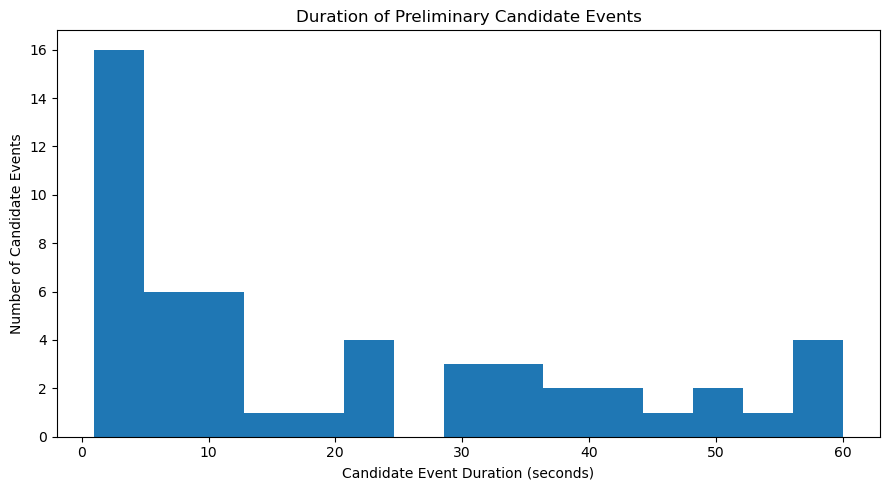

Saved figure to: ../reports/figures/pilot_candidate_event_duration.png


In [25]:
duration_figure_path = (
    FIGURE_DIR
    / "pilot_candidate_event_duration.png"
)

plt.figure(figsize=(9, 5))

plt.hist(
    features["event_duration_seconds"].dropna(),
    bins=15,
)

plt.title("Duration of Preliminary Candidate Events")
plt.xlabel("Candidate Event Duration (seconds)")
plt.ylabel("Number of Candidate Events")
plt.tight_layout()

plt.savefig(
    duration_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure to: {duration_figure_path}")

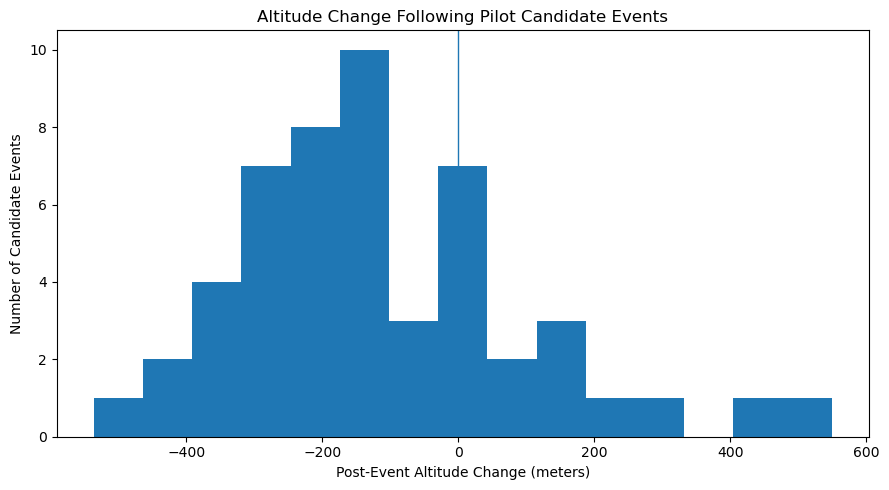

Saved figure to: ../reports/figures/pilot_post_event_altitude_change.png


In [26]:
altitude_change_figure_path = (
    FIGURE_DIR
    / "pilot_post_event_altitude_change.png"
)

plt.figure(figsize=(9, 5))

plt.hist(
    features["post_altitude_change_m"].dropna(),
    bins=15,
)

plt.axvline(
    0,
    linewidth=1,
)

plt.title("Altitude Change Following Pilot Candidate Events")
plt.xlabel("Post-Event Altitude Change (meters)")
plt.ylabel("Number of Candidate Events")
plt.tight_layout()

plt.savefig(
    altitude_change_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure to: {altitude_change_figure_path}")

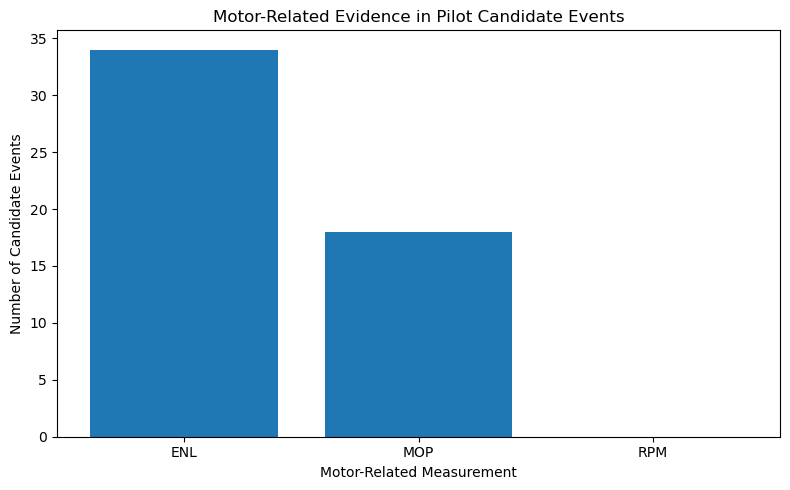

Saved figure to: ../reports/figures/pilot_candidate_motor_evidence.png


In [27]:
evidence_summary = pd.DataFrame({
    "Evidence_Source": [
        "ENL",
        "MOP",
        "RPM",
    ],
    "Candidate_Count": [
        int(features["ENL_evidence"].sum()),
        int(features["MOP_evidence"].sum()),
        int(features["RPM_evidence"].sum()),
    ],
})

evidence_figure_path = (
    FIGURE_DIR
    / "pilot_candidate_motor_evidence.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    evidence_summary["Evidence_Source"],
    evidence_summary["Candidate_Count"],
)

plt.title("Motor-Related Evidence in Pilot Candidate Events")
plt.xlabel("Motor-Related Measurement")
plt.ylabel("Number of Candidate Events")
plt.tight_layout()

plt.savefig(
    evidence_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure to: {evidence_figure_path}")

## 18. Create the Model-Ready Feature Table

The final pilot output retains event identifiers, source metadata, engineered predictors, data-quality fields, and placeholders needed for sponsor review and later decision-tree classification.

In [28]:
preferred_columns = [
    "event_id",
    "file",
    "event_group",
    "date",
    "glider_type",
    "recorder_type",
    "event_start_time_utc",
    "event_end_time_utc",
    "event_start_seconds",
    "event_end_seconds",
    "event_duration_seconds",
    "event_duration_log",
    "brief_event_indicator",
    "sustained_event_indicator",
    "start_latitude",
    "start_longitude",
    "pressure_altitude_at_start_m",
    "gnss_altitude_at_start_m",
    "analysis_altitude_at_start_m",
    "terrain_elevation_m",
    "start_agl_m",
    "applicable_agl_threshold_m",
    "above_required_agl",
    "pre_vertical_speed_mean_mps",
    "post_vertical_speed_mean_mps",
    "vertical_speed_change_mps",
    "post_altitude_change_m",
    "post_climb_indicator",
    "vertical_response_improved",
    "post_altitude_gain_indicator",
    "post_altitude_loss_indicator",
    "large_post_altitude_gain_indicator",
    "ENL_evidence",
    "MOP_evidence",
    "RPM_evidence",
    "ENL_event_max",
    "ENL_pre_median",
    "ENL_post_median",
    "ENL_increase_from_pre",
    "ENL_relative_increase",
    "MOP_event_max",
    "MOP_pre_median",
    "MOP_post_median",
    "MOP_increase_from_pre",
    "MOP_relative_increase",
    "RPM_event_max",
    "RPM_pre_median",
    "RPM_post_median",
    "RPM_increase_from_pre",
    "RPM_relative_increase",
    "available_motor_sensor_count",
    "observed_motor_signal_count",
    "motor_evidence_coverage",
    "descriptive_evidence_count",
    "ENL_available",
    "MOP_available",
    "RPM_available",
    "TAS_available",
    "GSP_available",
    "VAT_available",
    "ACZ_available",
    "pre_window_rows",
    "post_window_rows",
    "pre_window_complete",
    "post_window_complete",
    "complete_event_context",
    "missing_start_altitude",
    "missing_start_location",
    "missing_vertical_response",
    "source_processing_status",
    "source_time_series_rows",
    "source_candidate_event_count",
    "sponsor_verified_label",
    "decision_tree_classification",
    "manual_review_status",
    "review_notes",
]

model_ready_columns = [
    column
    for column in preferred_columns
    if column in features.columns
]

model_ready_features = (
    features[model_ready_columns]
    .copy()
)

print(f"Model-ready rows: {len(model_ready_features):,}")
print(
    f"Model-ready columns: "
    f"{len(model_ready_features.columns):,}"
)

model_ready_features.head()

Model-ready rows: 52
Model-ready columns: 76


,event_id,file,event_group,date,glider_type,recorder_type,event_start_time_utc,event_end_time_utc,event_start_seconds,event_end_seconds,...,missing_start_altitude,missing_start_location,missing_vertical_response,source_processing_status,source_time_series_rows,source_candidate_event_count,sponsor_verified_label,decision_tree_classification,manual_review_status,review_notes
0,4536-9239003137.igc__event_1,4536-9239003137.igc,1,"110824,1",JS-3-18m_2L,"LXNAV,LX9070PF",18:33:58,18:34:09,66838.0,66849.0,...,False,False,False,processed,13618,1,<NA>,<NA>,not reviewed,
1,4536-9239003138.igc__event_1,4536-9239003138.igc,1,"110824,1",18m AS33 @ventus,"LXNAV,LX9070PF",21:42:40,21:42:40,78160.0,78160.0,...,False,False,False,processed,12240,2,<NA>,<NA>,not reviewed,
2,4536-9239003138.igc__event_2,4536-9239003138.igc,2,"110824,1",18m AS33 @ventus,"LXNAV,LX9070PF",21:43:34,21:43:34,78214.0,78214.0,...,False,False,False,processed,12240,2,<NA>,<NA>,not reviewed,
3,4536-9239003143.igc__event_1,4536-9239003143.igc,1,NaN,AS 33Es 18m,"LXNAV,LX9070",19:01:25,19:01:25,68485.0,68485.0,...,False,False,False,processed,14112,1,<NA>,<NA>,not reviewed,
4,4536-9239003145.igc__event_1,4536-9239003145.igc,1,NaN,Ventus 3M,"LXNAV,LX9070",18:56:06,18:56:17,68166.0,68177.0,...,False,False,False,processed,14657,22,<NA>,<NA>,not reviewed,


## 19. Validate the Final Feature Table

The final checks confirm that every row has a unique event identifier and that the number of events has not changed during feature engineering.

In [29]:
assert len(model_ready_features) == len(candidates), (
    "The number of feature rows does not match "
    "the original number of candidates."
)

assert model_ready_features["event_id"].notna().all(), (
    "One or more rows are missing an event ID."
)

assert not model_ready_features["event_id"].duplicated().any(), (
    "Duplicate event IDs were found."
)

print("Final validation passed.")
print(f"Candidate rows retained: {len(model_ready_features):,}")

Final validation passed.
Candidate rows retained: 52


## 20. Save Feature-Engineering Outputs

In [30]:
model_ready_features.to_csv(
    FEATURE_OUTPUT_PATH,
    index=False,
)

quality_summary.to_csv(
    QUALITY_OUTPUT_PATH,
    index=False,
)

print("\nFeature-engineering outputs saved successfully.")
print(f"Feature dataset: {FEATURE_OUTPUT_PATH}")
print(f"Quality summary: {QUALITY_OUTPUT_PATH}")


Feature-engineering outputs saved successfully.
Feature dataset: ../data/processed/wgc_engine_start_features_pilot.csv
Quality summary: ../data/processed/wgc_feature_engineering_quality_summary.csv


## 21. Current Assumptions and Limitations

The feature-engineering results remain preliminary for several reasons:

- The input contains candidates from a 10-flight pilot rather than the complete archive.
- Candidate events were generated using exploratory activity thresholds and grouping rules.
- ENL, MOP, and RPM availability differs across aircraft and recorder systems.
- Recorded signal scales may not be directly comparable across hardware systems.
- Some candidates have incomplete pre-event or post-event windows.
- Positive altitude change does not independently prove successful engine operation.
- The 5-second, 20-second, and 30-meter indicators are exploratory.
- The current altitude values are not altitude above ground level.
- Terrain elevation must be integrated before the altitude-threshold question can be answered.
- Sponsor-confirmed successful and unsuccessful examples have not yet been merged with the feature table.
- No precision, recall, F1 score, or final model accuracy can be calculated until verified labels are available.

## 22. Preliminary Conclusions

This notebook converts the 52 preliminary candidate events produced in Notebook 4 into a standardized event-level feature dataset for manual review and later classification.

The engineered features summarize motor-related activity, event duration, aircraft vertical response, post-event altitude change, aircraft and recorder metadata, sensor availability, and event-level data-quality limitations. Together, these fields provide a consistent and interpretable input for our decision-tree classification process.

The current output does not represent final engine-start classifications or altitude-compliance findings. The next steps are to incorporate terrain elevation, confirm the applicable AGL threshold, finalize the decision-tree criteria, and validate the workflow on sponsor-reviewed examples before applying it to the complete WGC archive.

## 23. Deliverables Produced

This notebook produces:

### Processed Data

- `wgc_engine_start_features_pilot.csv`
- `wgc_feature_engineering_quality_summary.csv`

### Figures

- `pilot_candidate_event_duration.png`
- `pilot_post_event_altitude_change.png`
- `pilot_candidate_motor_evidence.png`

### Reusable Analysis Outputs

- unique event identifiers
- aircraft and recorder metadata
- motor-signal change features
- flight-response features
- timing and duration features
- sensor-availability summaries
- event-level data-quality fields
- a transparent descriptive evidence count
- placeholders for sponsor labels, terrain elevation, AGL, threshold comparison, and final classifications

These outputs will serve as input for the project’s decision-tree classification and validation stages.